# Longitudinal GCaMP activity and connectivity: BP vs IOBP

This notebook compares **BP** and **IOBP** at each experimental day. The primary replicate is one recording/well (for example, `1-1`); individual neurons and groups are retained only for descriptive distribution plots.

Definitions used here:

- **Detected ROIs:** number of rows in Suite2p `F.npy` (with classifier-table reconstruction as a fallback).
- **Active ROIs:** ROIs retained by the activity classifier, represented by rows in `spike_summary`.
- **Spike rate:** `spike_frequency` in Hz, summarized within each recording before BP–IOBP inference.
- **Connectivity:** combined groups in `grouping_stats`, summarized as group count, group size, and fraction of active ROIs assigned to a group.
- A folder without a `_DayN` suffix is **Day 1**. Thus `1-1`, `1-2`, etc. are replicate IDs, not timepoint strata.

The BP–IOBP tests are unpaired by default. Set `PAIRED_BP_IOBP = True` only if matching recording labels identify the same biological units under both treatments.

In [1]:
from pathlib import Path
import ast
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

# Change this path if the dataset is moved.
DATA_ROOT = Path(r"C:\Users\mzinn1\Desktop\DailyRecordings_LateTimepoints")
OUTPUT_DIR = Path(
    r"C:\Users\mzinn1\Desktop\Scripts\GCaMP-analysis"
    r"\notebooks\visualization_outputs_all_timepoints"
)
OUTPUT_DIR.mkdir(exist_ok=True)

TREATMENT_ORDER = ["BP", "IOBP"]
PALETTE = {"BP": "#3B82F6", "IOBP": "#F97316"}
PAIRED_BP_IOBP = False
SAVE_FIGURES = True

assert DATA_ROOT.exists(), f"Data root not found: {DATA_ROOT}"
print(f"Reading data from: {DATA_ROOT}")

Reading data from: C:\Users\mzinn1\Desktop\DailyRecordings_LateTimepoints


## Load and validate the per-recording metrics

The loader discovers workbooks recursively, parses the day from the folder name, and preserves three tidy tables: recording-level summaries, active-neuron spike rates, and connectivity-group rows. QC columns make discrepancies between Suite2p and the classifier tables visible rather than silently discarding them.

In [2]:
DAY_RE = re.compile(r"_Day(\d+)$", flags=re.IGNORECASE)


def parse_recording_name(folder_name):
    match = DAY_RE.search(folder_name)
    day = int(match.group(1)) if match else 1
    recording = DAY_RE.sub("", folder_name)
    return recording, day


def safe_list(value):
    if isinstance(value, (list, tuple, np.ndarray)):
        return list(value)
    if pd.isna(value):
        return []
    try:
        parsed = ast.literal_eval(str(value))
        return list(parsed) if isinstance(parsed, (list, tuple, np.ndarray)) else []
    except (ValueError, SyntaxError):
        return []


def load_one_workbook(path, treatment):
    folder = path.parent.parent
    recording, day = parse_recording_name(folder.name)
    excel = pd.ExcelFile(path)

    spike = (
        pd.read_excel(path, sheet_name="spike_summary")
        if "spike_summary" in excel.sheet_names
        else pd.DataFrame()
    )
    bad = (
        pd.read_excel(path, sheet_name="bad_rois_features")
        if "bad_rois_features" in excel.sheet_names
        else pd.DataFrame()
    )
    groups = (
        pd.read_excel(path, sheet_name="grouping_stats")
        if "grouping_stats" in excel.sheet_names
        else pd.DataFrame()
    )
    if not groups.empty and "method" in groups:
        groups = groups.loc[groups["method"].astype(str).str.lower() == "combined"].copy()

    f_path = folder / "suite2p" / "plane0" / "F.npy"
    iscell_path = folder / "suite2p" / "plane0" / "iscell.npy"
    if f_path.exists():
        suite2p_roi_count = int(np.load(f_path, mmap_mode="r").shape[0])
    elif iscell_path.exists():
        suite2p_roi_count = int(np.load(iscell_path, mmap_mode="r").shape[0])
    else:
        suite2p_roi_count = np.nan

    active_count = int(len(spike))
    inactive_count = int(len(bad))
    classifier_accounted = active_count + inactive_count
    detected_count = (
        int(suite2p_roi_count) if pd.notna(suite2p_roi_count) else classifier_accounted
    )

    if not spike.empty:
        spike_rate = pd.to_numeric(spike.get("spike_frequency"), errors="coerce")
        spike_mean = float(spike_rate.mean())
        spike_median = float(spike_rate.median())
        zero_spike_fraction = float(spike_rate.eq(0).mean())
    else:
        spike_mean = spike_median = zero_spike_fraction = np.nan

    if not groups.empty:
        group_sizes = pd.to_numeric(groups.get("number_neurons"), errors="coerce")
        member_ids = set()
        if "neuron_indices" in groups:
            for value in groups["neuron_indices"]:
                member_ids.update(safe_list(value))
        grouped_active_count = len(member_ids)
        n_groups = int(group_sizes.notna().sum())
        mean_group_size = float(group_sizes.mean())
        median_group_size = float(group_sizes.median())
    else:
        grouped_active_count = 0
        n_groups = 0
        # A recording can correctly have zero groups, but the size of a
        # nonexistent group is undefined rather than zero.
        mean_group_size = np.nan
        median_group_size = np.nan

    key = {
        "treatment": treatment,
        "recording": recording,
        "day": day,
        "recording_folder": folder.name,
    }
    summary = {
        **key,
        "metrics_path": str(path),
        "detected_roi_count": detected_count,
        "active_roi_count": active_count,
        "inactive_roi_count": inactive_count,
        "classifier_accounted_roi_count": classifier_accounted,
        "suite2p_roi_count": suite2p_roi_count,
        "roi_accounting_difference": classifier_accounted - detected_count,
        "active_fraction": active_count / detected_count if detected_count else np.nan,
        "mean_spike_rate_hz": spike_mean,
        "median_spike_rate_hz": spike_median,
        "zero_spike_active_fraction": zero_spike_fraction,
        "n_groups": n_groups,
        "mean_group_size": mean_group_size,
        "median_group_size": median_group_size,
        "grouped_active_count": grouped_active_count,
        "fraction_active_grouped": grouped_active_count / active_count if active_count else np.nan,
        "groups_per_1000_detected_rois": (
            1000 * n_groups / detected_count if detected_count else np.nan
        ),
        "fraction_detected_rois_grouped": (
            grouped_active_count / detected_count if detected_count else np.nan
        ),
    }

    if not spike.empty:
        spike = spike.copy()
        for column, value in key.items():
            spike[column] = value
    if not groups.empty:
        groups = groups.copy()
        for column, value in key.items():
            groups[column] = value

    return summary, spike, groups


summaries, spike_tables, group_tables = [], [], []
for treatment in TREATMENT_ORDER:
    for path in sorted((DATA_ROOT / treatment).glob("*/metrics/*_metrics.xlsx")):
        summary, spike, groups = load_one_workbook(path, treatment)
        summaries.append(summary)
        if not spike.empty:
            spike_tables.append(spike)
        if not groups.empty:
            group_tables.append(groups)

recording_df = pd.DataFrame(summaries).sort_values(["day", "treatment", "recording"])
spike_df = pd.concat(spike_tables, ignore_index=True) if spike_tables else pd.DataFrame()
group_df = pd.concat(group_tables, ignore_index=True) if group_tables else pd.DataFrame()
day_order = sorted(recording_df["day"].unique())

print(f"Loaded {len(recording_df)} recordings, {len(spike_df):,} active-neuron rows, "
      f"and {len(group_df):,} group rows.")
display(recording_df.head())

Loaded 108 recordings, 26,172 active-neuron rows, and 1,327 group rows.


,treatment,recording,day,recording_folder,metrics_path,detected_roi_count,active_roi_count,inactive_roi_count,classifier_accounted_roi_count,suite2p_roi_count,...,mean_spike_rate_hz,median_spike_rate_hz,zero_spike_active_fraction,n_groups,mean_group_size,median_group_size,grouped_active_count,fraction_active_grouped,groups_per_1000_detected_rois,fraction_detected_rois_grouped
0,BP,1-1,1,1-1,C:\Users\mzinn1\Desktop\DailyRecordings_LateTi...,2102,24,2078,2102,2102.0,...,0.070820,0.074257,0.0,1,2.0,2.0,2,0.083333,0.475737,0.000951
10,BP,1-2,1,1-2,C:\Users\mzinn1\Desktop\DailyRecordings_LateTi...,1136,33,1103,1136,1136.0,...,0.061756,0.049505,0.0,3,2.0,2.0,6,0.181818,2.640845,0.005282
21,BP,1-3,1,1-3,C:\Users\mzinn1\Desktop\DailyRecordings_LateTi...,1393,34,1359,1393,1393.0,...,0.055572,0.041254,0.0,1,2.0,2.0,2,0.058824,0.717875,0.001436
32,BP,1-4,1,1-4,C:\Users\mzinn1\Desktop\DailyRecordings_LateTi...,1065,23,1042,1065,1065.0,...,0.057397,0.057756,0.0,0,NaN,NaN,0,0.000000,0.000000,0.000000
43,BP,1-5,1,1-5,C:\Users\mzinn1\Desktop\DailyRecordings_LateTi...,1896,47,1849,1896,1896.0,...,0.052665,0.049505,0.0,3,2.0,2.0,6,0.127660,1.582278,0.003165


In [3]:
# Replicate coverage and ROI-accounting QC
coverage = (
    recording_df.groupby(["day", "treatment"], observed=True)
    .agg(
        n_recordings=("recording", "size"),
        recording_ids=("recording", lambda x: ", ".join(sorted(x))),
    )
    .reset_index()
)
display(coverage)

qc = recording_df.loc[
    recording_df["roi_accounting_difference"].ne(0),
    ["treatment", "recording", "day", "suite2p_roi_count",
     "classifier_accounted_roi_count", "roi_accounting_difference"],
]
print(f"ROI-accounting discrepancies: {len(qc)} recording(s)")
display(qc if not qc.empty else pd.DataFrame({"status": ["All ROI counts reconcile"]}))

,day,treatment,n_recordings,recording_ids
0,1,BP,5,"1-1, 1-2, 1-3, 1-4, 1-5"
1,1,IOBP,5,"1-1, 1-2, 1-3, 1-4, 1-5"
2,2,BP,5,"1-1, 1-2, 1-3, 1-4, 1-5"
3,2,IOBP,5,"1-1, 1-2, 1-3, 1-4, 1-5"
4,3,BP,5,"1-1, 1-2, 1-3, 1-4, 1-5"
5,3,IOBP,5,"1-1, 1-2, 1-3, 1-4, 1-5"
6,4,BP,5,"1-1, 1-2, 1-3, 1-4, 1-5"
7,4,IOBP,5,"1-1, 1-2, 1-3, 1-4, 1-5"
8,5,BP,5,"1-1, 1-2, 1-3, 1-4, 1-5"
9,5,IOBP,5,"1-1, 1-2, 1-3, 1-4, 1-5"


ROI-accounting discrepancies: 8 recording(s)


,treatment,recording,day,suite2p_roi_count,classifier_accounted_roi_count,roi_accounting_difference
20,BP,1-2,7,1006.0,1004,-2
64,IOBP,1-1,7,989.0,988,-1
77,IOBP,1-3,10,1252.0,1251,-1
89,IOBP,1-4,13,766.0,765,-1
69,IOBP,1-2,21,571.0,570,-1
80,IOBP,1-3,21,1031.0,1030,-1
92,IOBP,1-4,28,704.0,703,-1
102,IOBP,1-5,28,621.0,620,-1


## Plotting helpers

Dots are individual recording-level observations. Lines and error bars show the treatment mean and 95% bootstrap confidence interval. This keeps the day as the main stratification while showing the underlying replicate count and spread.

In [4]:
def recording_plot(ax, data, y, ylabel, *, percent=False):
    sns.stripplot(
        data=data, x="day", y=y, hue="treatment", hue_order=TREATMENT_ORDER,
        order=day_order, dodge=True, jitter=0.10, alpha=0.58, size=5,
        palette=PALETTE, ax=ax, legend=False,
    )
    sns.pointplot(
        data=data, x="day", y=y, hue="treatment", hue_order=TREATMENT_ORDER,
        order=day_order, dodge=0.35, estimator="mean", errorbar=("ci", 95),
        n_boot=3000, markers=["o", "s"], linestyles=["-", "-"],
        palette=PALETTE, ax=ax,
    )
    ax.set_xlabel("Day")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    if percent:
        ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
    sns.despine(ax=ax)


def finish_figure(fig, filename):
    fig.tight_layout()
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / filename, dpi=220, bbox_inches="tight")
    plt.show()

## Detected ROIs versus active ROIs

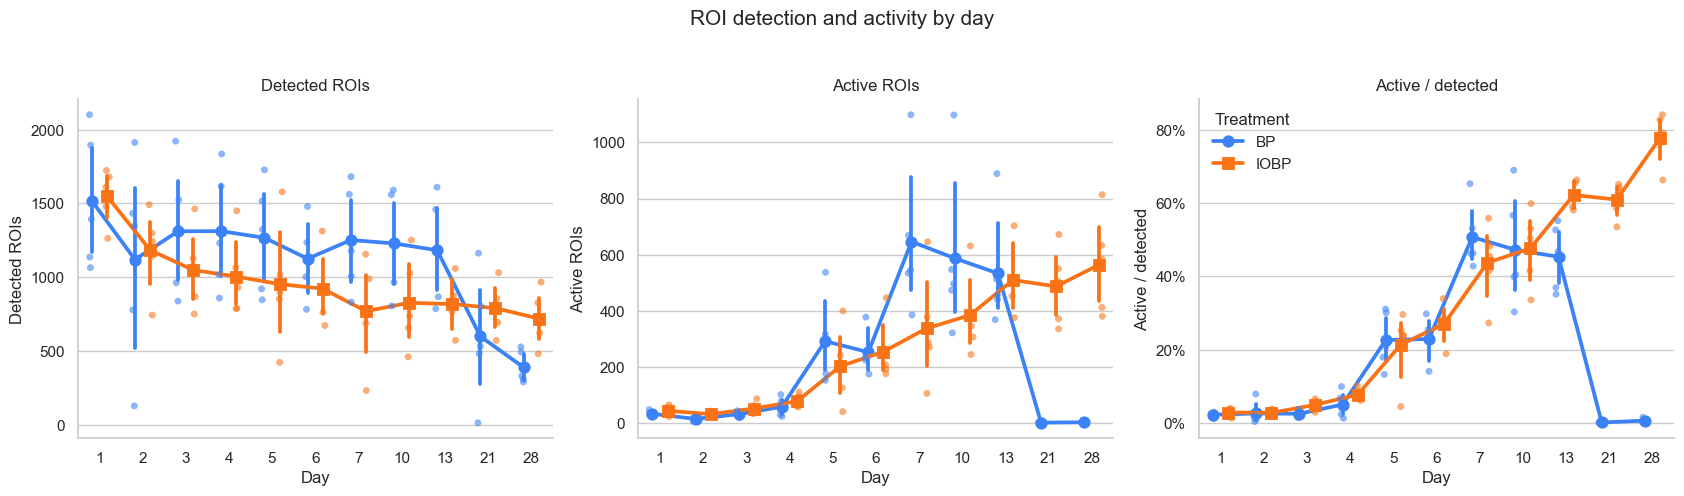

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
recording_plot(axes[0], recording_df, "detected_roi_count", "Detected ROIs")
recording_plot(axes[1], recording_df, "active_roi_count", "Active ROIs")
recording_plot(axes[2], recording_df, "active_fraction", "Active / detected", percent=True)
handles, labels = axes[2].get_legend_handles_labels()
for ax in axes[:2]:
    legend = ax.get_legend()
    if legend:
        legend.remove()
axes[2].legend(handles[:2], labels[:2], title="Treatment", frameon=False)
fig.suptitle("ROI detection and activity by day", y=1.03, fontsize=15)
finish_figure(fig, "01_roi_detected_vs_active.png")

## Activity level in spike rate

The inferential unit remains the recording. The first figure shows recording-level mean and median active-neuron rates. The second figure is a descriptive neuron-level distribution and should not be interpreted as if every neuron were an independent biological replicate.

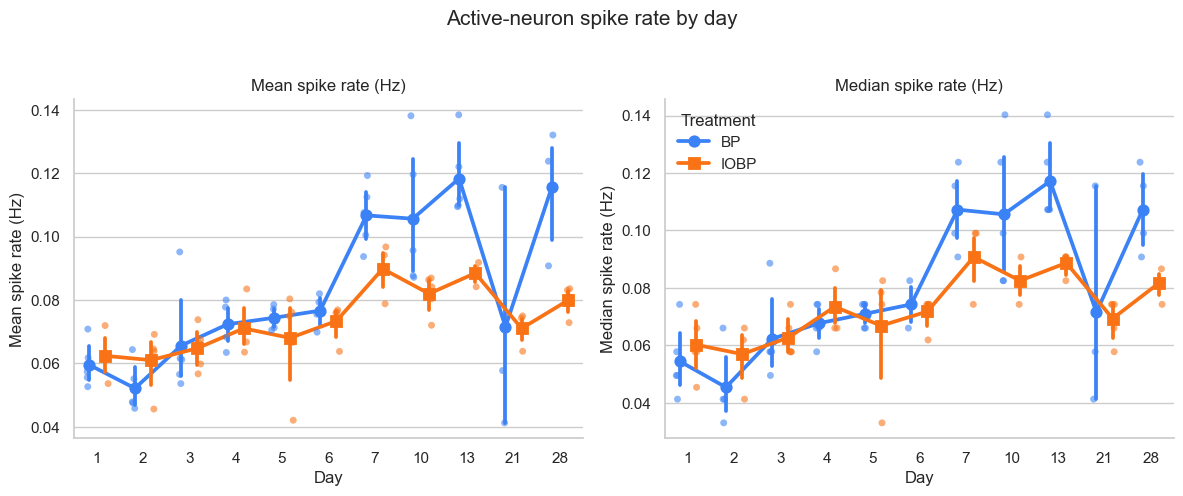

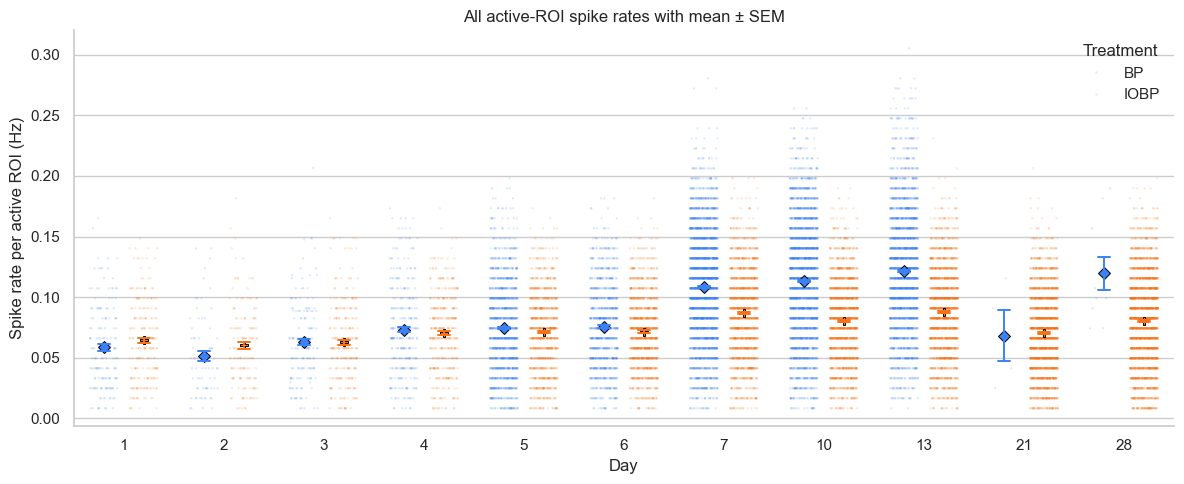

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
recording_plot(axes[0], recording_df, "mean_spike_rate_hz", "Mean spike rate (Hz)")
recording_plot(axes[1], recording_df, "median_spike_rate_hz", "Median spike rate (Hz)")
if axes[0].get_legend():
    axes[0].get_legend().remove()
axes[1].legend(title="Treatment", frameon=False)
fig.suptitle("Active-neuron spike rate by day", y=1.03, fontsize=15)
finish_figure(fig, "02_spike_rate_recording_summary.png")

fig, ax = plt.subplots(figsize=(12, 5))
sns.stripplot(
    data=spike_df, x="day", y="spike_frequency", hue="treatment",
    order=day_order, hue_order=TREATMENT_ORDER, palette=PALETTE,
    dodge=True, jitter=0.28, alpha=0.16, size=1.7, linewidth=0,
    rasterized=True, ax=ax,
)
sns.pointplot(
    data=spike_df, x="day", y="spike_frequency", hue="treatment",
    order=day_order, hue_order=TREATMENT_ORDER, palette=PALETTE,
    estimator="mean", errorbar="se", dodge=0.40, capsize=0.12,
    markers=["D", "P"], linestyles=["none", "none"],
    markersize=6, markeredgecolor="black", markeredgewidth=0.7,
    err_kws={"linewidth": 1.4}, legend=False, zorder=5, ax=ax,
)
ax.set(xlabel="Day", ylabel="Spike rate per active ROI (Hz)",
       title="All active-ROI spike rates with mean ± SEM")
ax.legend(title="Treatment", frameon=False)
sns.despine(ax=ax)
finish_figure(fig, "03_spike_rate_neuron_distributions.png")

## Connectivity: group number and size

`n_groups` is the number of combined connectivity groups in a recording. Group size is the number of active neurons in each group. Detected ROI count is used as an **exposure/denominator**, not as an independent sample size: `groups_per_1000_detected_rois` and `fraction_detected_rois_grouped` remain defined when a recording has zero groups. This avoids ROI-level pseudoreplication while accounting for unequal ROI detection across recordings.

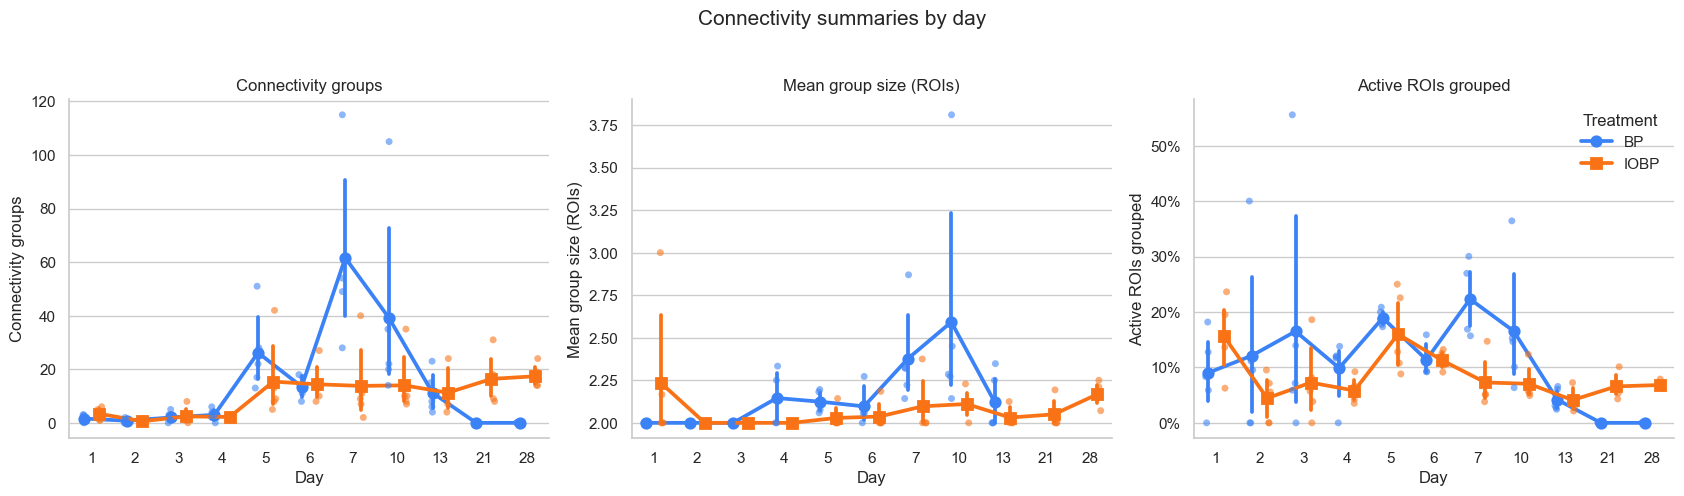

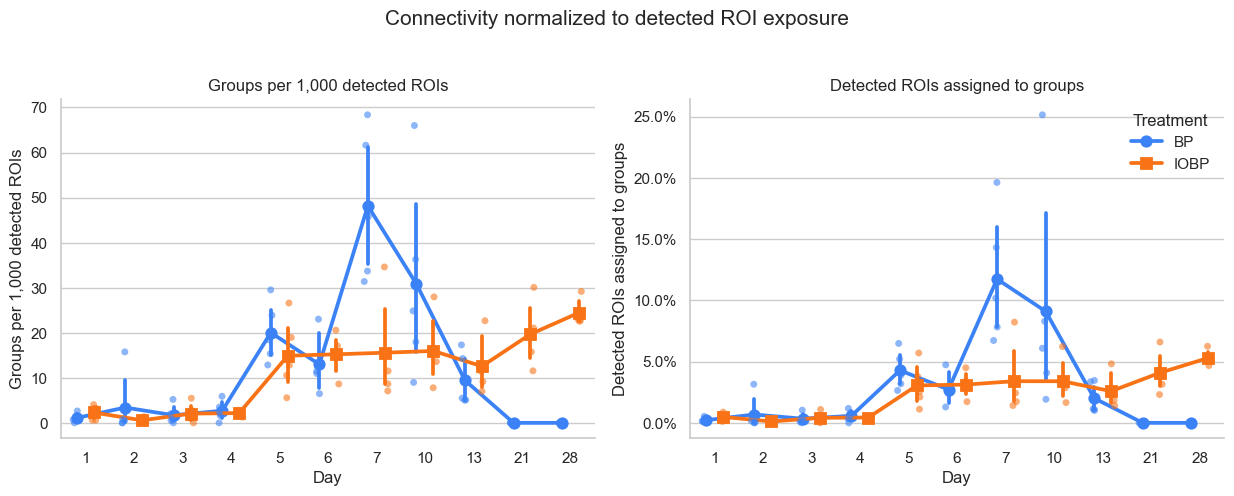

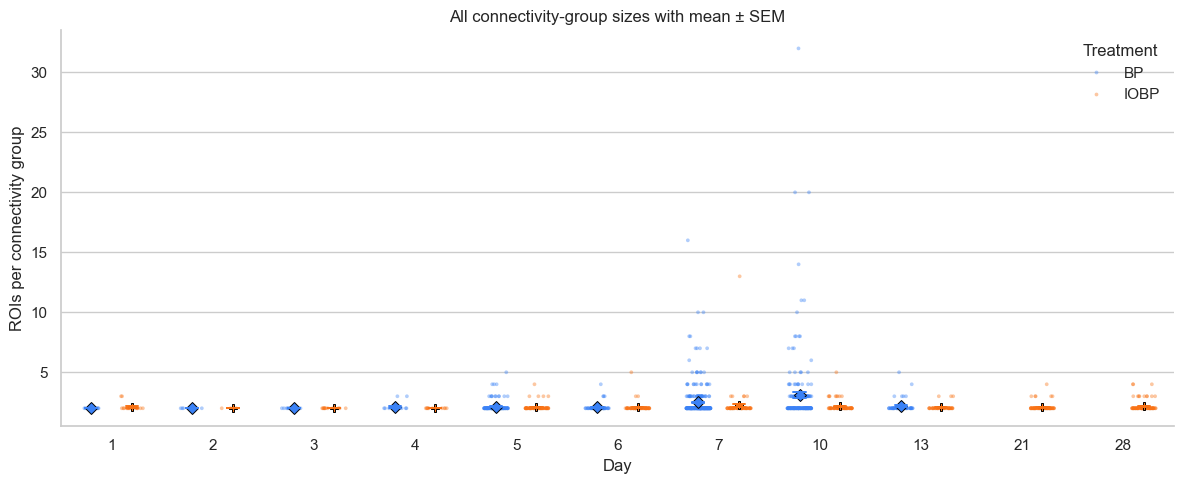

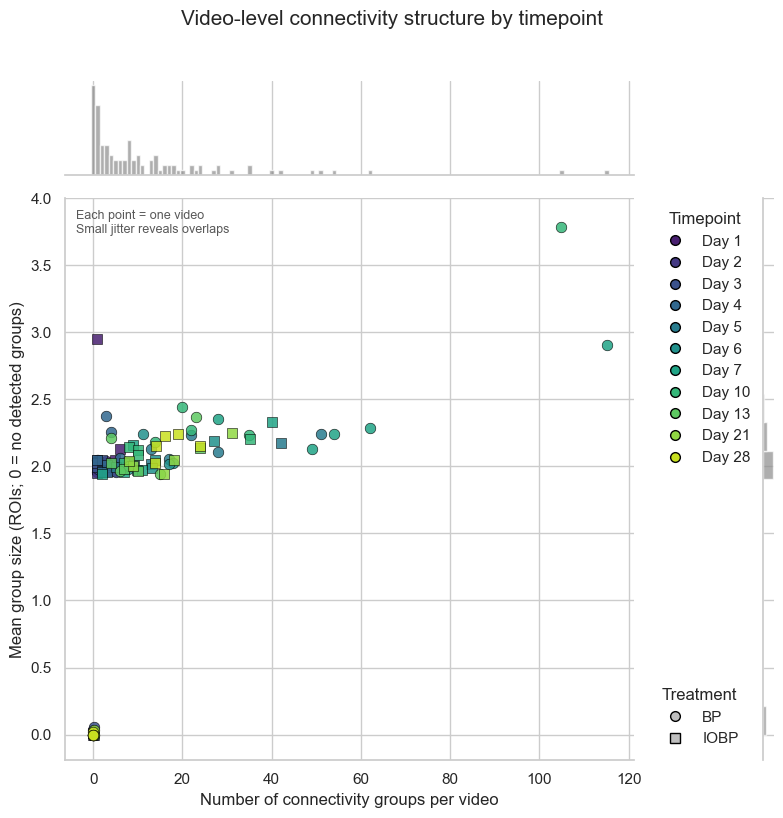

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
recording_plot(axes[0], recording_df, "n_groups", "Connectivity groups")
recording_plot(axes[1], recording_df, "mean_group_size", "Mean group size (ROIs)")
recording_plot(
    axes[2], recording_df, "fraction_active_grouped", "Active ROIs grouped", percent=True
)
for ax in axes[:2]:
    if ax.get_legend():
        ax.get_legend().remove()
axes[2].legend(title="Treatment", frameon=False)
fig.suptitle("Connectivity summaries by day", y=1.03, fontsize=15)
finish_figure(fig, "04_connectivity_recording_summary.png")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
recording_plot(
    axes[0], recording_df, "groups_per_1000_detected_rois",
    "Groups per 1,000 detected ROIs",
)
recording_plot(
    axes[1], recording_df, "fraction_detected_rois_grouped",
    "Detected ROIs assigned to groups", percent=True,
)
if axes[0].get_legend():
    axes[0].get_legend().remove()
axes[1].legend(title="Treatment", frameon=False)
fig.suptitle("Connectivity normalized to detected ROI exposure", y=1.03, fontsize=15)
finish_figure(fig, "04b_connectivity_normalized_to_detected_rois.png")

fig, ax = plt.subplots(figsize=(12, 5))
sns.stripplot(
    data=group_df, x="day", y="number_neurons", hue="treatment",
    order=day_order, hue_order=TREATMENT_ORDER, palette=PALETTE,
    dodge=True, jitter=0.24, alpha=0.40, size=2.7, linewidth=0,
    rasterized=True, ax=ax,
)
sns.pointplot(
    data=group_df, x="day", y="number_neurons", hue="treatment",
    order=day_order, hue_order=TREATMENT_ORDER, palette=PALETTE,
    estimator="mean", errorbar="se", dodge=0.40, capsize=0.12,
    markers=["D", "P"], linestyles=["none", "none"],
    markersize=6, markeredgecolor="black", markeredgewidth=0.7,
    err_kws={"linewidth": 1.4}, legend=False, zorder=5, ax=ax,
)
ax.set(xlabel="Day", ylabel="ROIs per connectivity group",
       title="All connectivity-group sizes with mean ± SEM")
ax.legend(title="Treatment", frameon=False)
sns.despine(ax=ax)
finish_figure(fig, "05_connectivity_group_size_distributions.png")

# Video-level joint view: group count versus mean group size.
# Zero-group videos are retained at y=0 because their mean group size is undefined.
from matplotlib.lines import Line2D

joint_df = recording_df[["recording", "treatment", "day", "n_groups", "mean_group_size"]].copy()
joint_df["mean_group_size_plot"] = joint_df["mean_group_size"].where(
    joint_df["n_groups"].gt(0), 0
)
# Small deterministic display-only jitter reveals videos with identical coordinates.
rng = np.random.default_rng(37)
joint_df["n_groups_plot"] = np.clip(
    joint_df["n_groups"] + rng.uniform(-0.11, 0.11, len(joint_df)), 0, None
)
joint_df["mean_group_size_display"] = np.clip(
    joint_df["mean_group_size_plot"] + rng.uniform(-0.06, 0.06, len(joint_df)), 0, None
)
day_palette = dict(zip(day_order, sns.color_palette("viridis", len(day_order))))
treatment_markers = {"BP": "o", "IOBP": "s"}

g = sns.JointGrid(
    data=joint_df, x="n_groups_plot", y="mean_group_size_display",
    height=8, ratio=5, space=0.08,
)
for day in day_order:
    for treatment in TREATMENT_ORDER:
        sub = joint_df.loc[
            joint_df["day"].eq(day) & joint_df["treatment"].eq(treatment)
        ]
        g.ax_joint.scatter(
            sub["n_groups_plot"], sub["mean_group_size_display"],
            c=[day_palette[day]], marker=treatment_markers[treatment],
            s=58, alpha=0.85, edgecolor="black", linewidth=0.45,
        )

x_bins = np.arange(-0.5, joint_df["n_groups"].max() + 1.5, 1)
g.ax_marg_x.hist(joint_df["n_groups"], bins=x_bins, color="0.55", alpha=0.70)
g.ax_marg_y.hist(
    joint_df["mean_group_size_plot"], bins=18, orientation="horizontal",
    color="0.55", alpha=0.70,
)
g.ax_joint.set(
    xlabel="Number of connectivity groups per video",
    ylabel="Mean group size (ROIs; 0 = no detected groups)",
)
g.ax_joint.text(
    0.02, 0.98, "Each point = one video\nSmall jitter reveals overlaps",
    transform=g.ax_joint.transAxes, va="top", fontsize=9, color="0.35",
)
day_handles = [
    Line2D([0], [0], marker="o", linestyle="none", label=f"Day {day}",
           markerfacecolor=day_palette[day], markeredgecolor="black", markersize=7)
    for day in day_order
]
treatment_handles = [
    Line2D([0], [0], marker=treatment_markers[treatment], linestyle="none",
           label=treatment, markerfacecolor="0.75", markeredgecolor="black", markersize=7)
    for treatment in TREATMENT_ORDER
]
day_legend = g.ax_joint.legend(
    handles=day_handles, title="Timepoint", frameon=False,
    loc="upper left", bbox_to_anchor=(1.02, 1.00),
)
g.ax_joint.add_artist(day_legend)
g.ax_joint.legend(
    handles=treatment_handles, title="Treatment", frameon=False,
    loc="lower left", bbox_to_anchor=(1.02, 0.00),
)
g.fig.suptitle("Video-level connectivity structure by timepoint", y=1.02, fontsize=15)
sns.despine(ax=g.ax_joint)
finish_figure(g.fig, "05b_connectivity_group_number_vs_size_joint.png")

## Longitudinal recording trajectories

These panels make the repeated-day structure explicit. Each faint line is one recording ID within a treatment; the thick line is the treatment mean. Missing timepoints remain missing rather than being imputed.

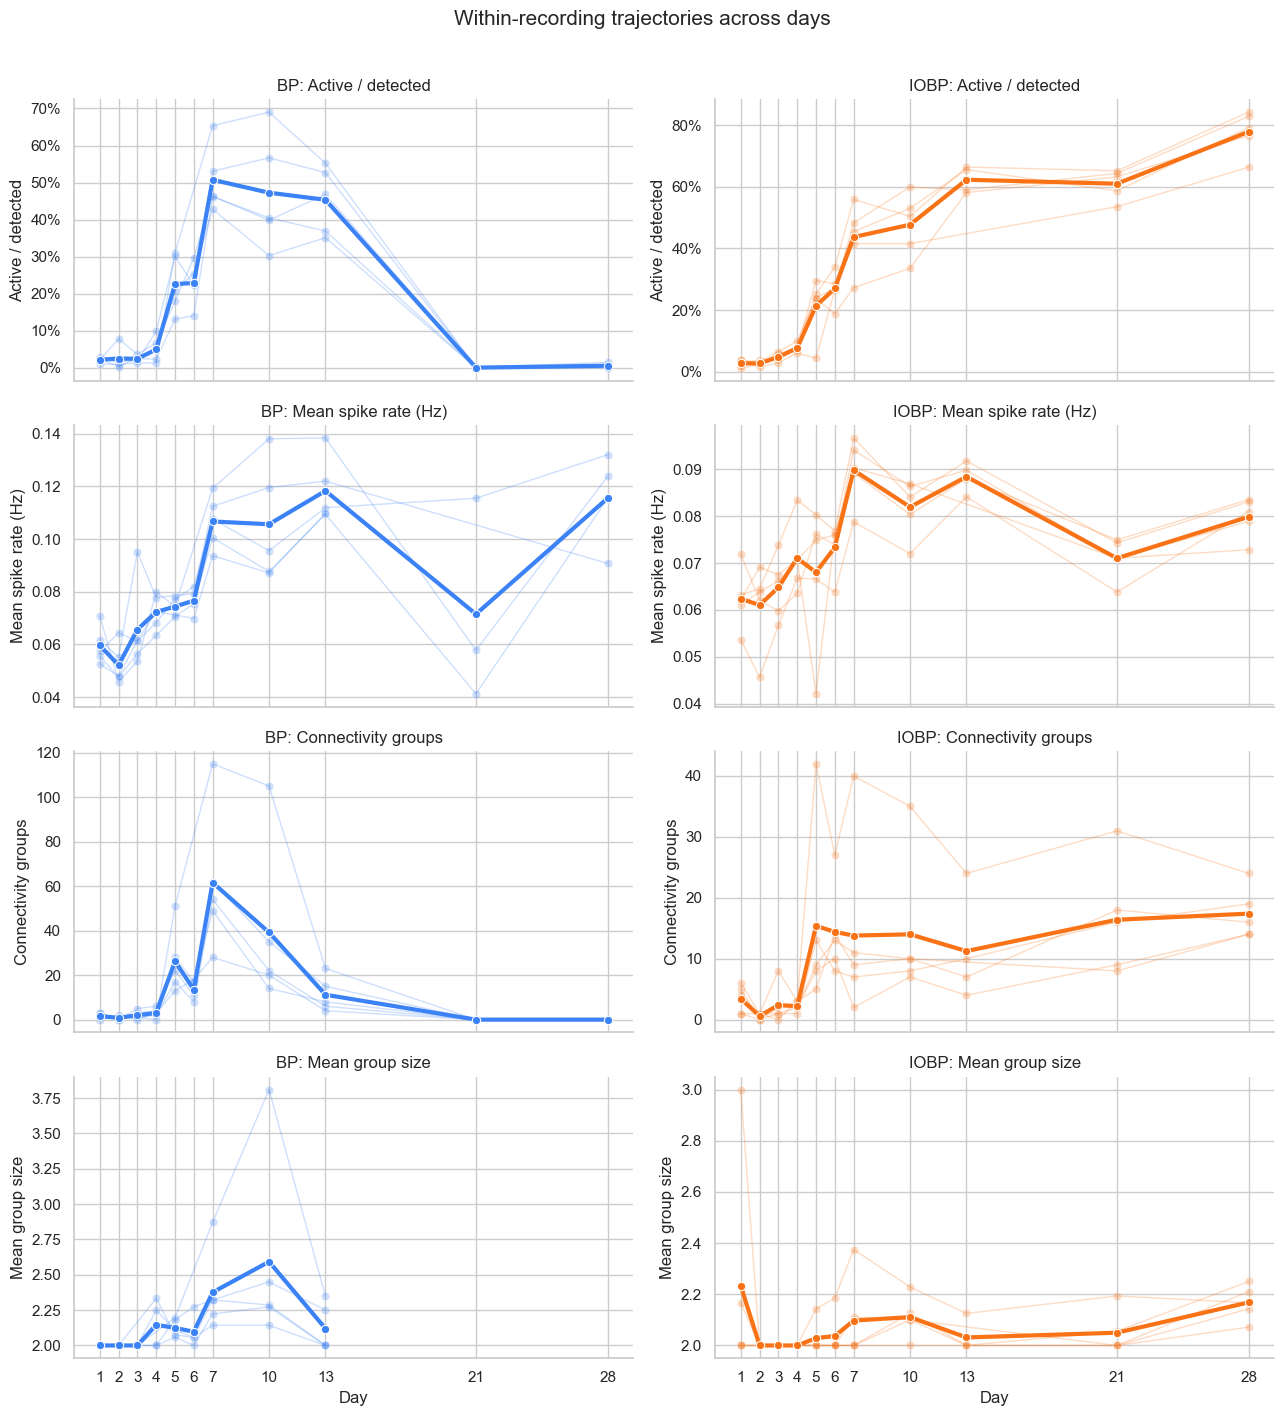

In [8]:
trajectory_metrics = [
    ("active_fraction", "Active / detected", True),
    ("mean_spike_rate_hz", "Mean spike rate (Hz)", False),
    ("n_groups", "Connectivity groups", False),
    ("mean_group_size", "Mean group size", False),
]
fig, axes = plt.subplots(len(trajectory_metrics), 2, figsize=(13, 14), sharex=True)
for row, (metric, label, percent) in enumerate(trajectory_metrics):
    for col, treatment in enumerate(TREATMENT_ORDER):
        ax = axes[row, col]
        sub = recording_df.loc[recording_df["treatment"].eq(treatment)]
        sns.lineplot(
            data=sub, x="day", y=metric, units="recording", estimator=None,
            color=PALETTE[treatment], alpha=0.25, linewidth=1, marker="o", ax=ax,
        )
        sns.lineplot(
            data=sub, x="day", y=metric, estimator="mean", errorbar=None,
            color=PALETTE[treatment], linewidth=3, marker="o", ax=ax,
        )
        ax.set(title=f"{treatment}: {label}", xlabel="Day", ylabel=label)
        ax.set_xticks(day_order)
        if percent:
            ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
        sns.despine(ax=ax)
fig.suptitle("Within-recording trajectories across days", y=1.01, fontsize=15)
finish_figure(fig, "06_longitudinal_recording_trajectories.png")

## BP versus IOBP at each day

For each outcome and day, the table reports treatment sample sizes, medians, the median difference (`IOBP - BP`), and a two-sided test. By default this is the Mann–Whitney U test on recording-level summaries. If pairing is explicitly enabled, only matching recording IDs are used with the Wilcoxon signed-rank test. Benjamini–Hochberg adjusted p-values control false discovery rate across the displayed outcome-by-day tests.

In [9]:
def bh_adjust(pvalues):
    p = np.asarray(pvalues, dtype=float)
    out = np.full(p.shape, np.nan)
    valid = np.flatnonzero(np.isfinite(p))
    if not len(valid):
        return out
    order = valid[np.argsort(p[valid])]
    ranked = p[order] * len(order) / np.arange(1, len(order) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    out[order] = np.clip(ranked, 0, 1)
    return out


def compare_treatments(data, metrics, paired=False):
    rows = []
    for metric, label in metrics.items():
        for day in day_order:
            sub = data.loc[data["day"].eq(day), ["treatment", "recording", metric]].dropna()
            bp = sub.loc[sub["treatment"].eq("BP"), ["recording", metric]]
            iobp = sub.loc[sub["treatment"].eq("IOBP"), ["recording", metric]]
            if paired:
                paired_df = bp.merge(iobp, on="recording", suffixes=("_BP", "_IOBP"))
                x = paired_df[f"{metric}_BP"].to_numpy()
                y = paired_df[f"{metric}_IOBP"].to_numpy()
                if len(x) >= 2 and np.any(x != y):
                    statistic, pvalue = stats.wilcoxon(x, y, alternative="two-sided")
                else:
                    statistic, pvalue = np.nan, np.nan
                test = "Wilcoxon paired"
            else:
                x = bp[metric].to_numpy()
                y = iobp[metric].to_numpy()
                if len(x) >= 2 and len(y) >= 2:
                    statistic, pvalue = stats.mannwhitneyu(x, y, alternative="two-sided")
                else:
                    statistic, pvalue = np.nan, np.nan
                test = "Mann–Whitney U"
            rows.append({
                "outcome": label,
                "day": day,
                "test": test,
                "n_BP": len(x),
                "n_IOBP": len(y),
                "median_BP": np.nanmedian(x) if len(x) else np.nan,
                "median_IOBP": np.nanmedian(y) if len(y) else np.nan,
                "median_difference_IOBP_minus_BP": (
                    np.nanmedian(y) - np.nanmedian(x) if len(x) and len(y) else np.nan
                ),
                "statistic": statistic,
                "p_value": pvalue,
            })
    result = pd.DataFrame(rows)
    result["p_fdr_bh"] = bh_adjust(result["p_value"])
    result["fdr_0.05"] = result["p_fdr_bh"].lt(0.05)
    return result


outcomes = {
    "detected_roi_count": "Detected ROIs",
    "active_roi_count": "Active ROIs",
    "active_fraction": "Active / detected",
    "mean_spike_rate_hz": "Mean spike rate (Hz)",
    "n_groups": "Connectivity groups",
    "mean_group_size": "Mean group size",
    "fraction_active_grouped": "Active ROIs grouped",
    "groups_per_1000_detected_rois": "Groups / 1,000 detected ROIs",
    "fraction_detected_rois_grouped": "Detected ROIs grouped",
}
comparison_df = compare_treatments(recording_df, outcomes, paired=PAIRED_BP_IOBP)
display(comparison_df.round(4))

,outcome,day,test,n_BP,n_IOBP,median_BP,median_IOBP,median_difference_IOBP_minus_BP,statistic,p_value,p_fdr_bh,fdr_0.05
0,Detected ROIs,1,Mann–Whitney U,5,5,1393.0000,1611.0000,218.0000,11.0,0.8413,0.9600,False
1,Detected ROIs,2,Mann–Whitney U,5,5,1347.0000,1243.0000,-104.0000,14.0,0.8413,0.9600,False
2,Detected ROIs,3,Mann–Whitney U,5,5,1310.0000,1034.0000,-276.0000,17.0,0.4206,0.6375,False
3,Detected ROIs,4,Mann–Whitney U,5,5,1231.0000,932.0000,-299.0000,19.0,0.2222,0.4491,False
4,Detected ROIs,5,Mann–Whitney U,5,5,1324.0000,897.0000,-427.0000,17.0,0.4206,0.6375,False
...,...,...,...,...,...,...,...,...,...,...,...,...
94,Detected ROIs grouped,7,Mann–Whitney U,5,5,0.1018,0.0243,-0.0775,23.0,0.0317,0.1260,False
95,Detected ROIs grouped,10,Mann–Whitney U,5,5,0.0609,0.0304,-0.0304,19.0,0.2222,0.4491,False
96,Detected ROIs grouped,13,Mann–Whitney U,5,4,0.0115,0.0206,0.0091,6.0,0.4127,0.6375,False
97,Detected ROIs grouped,21,Mann–Whitney U,5,5,0.0000,0.0401,0.0401,0.0,0.0075,0.0815,False


## Significance-level visualization

The heatmaps encode significance as $-\log_{10}(p)$, so darker cells indicate stronger evidence. Each cell also reports the exact value and a conventional significance label. The **nominal p-value** panel is exploratory; the **FDR-adjusted q-value** panel is the primary multiple-comparison-aware interpretation.

Significance labels: `ns` ≥ 0.05, `*` < 0.05, `**` < 0.01, `***` < 0.001, `****` < 0.0001.

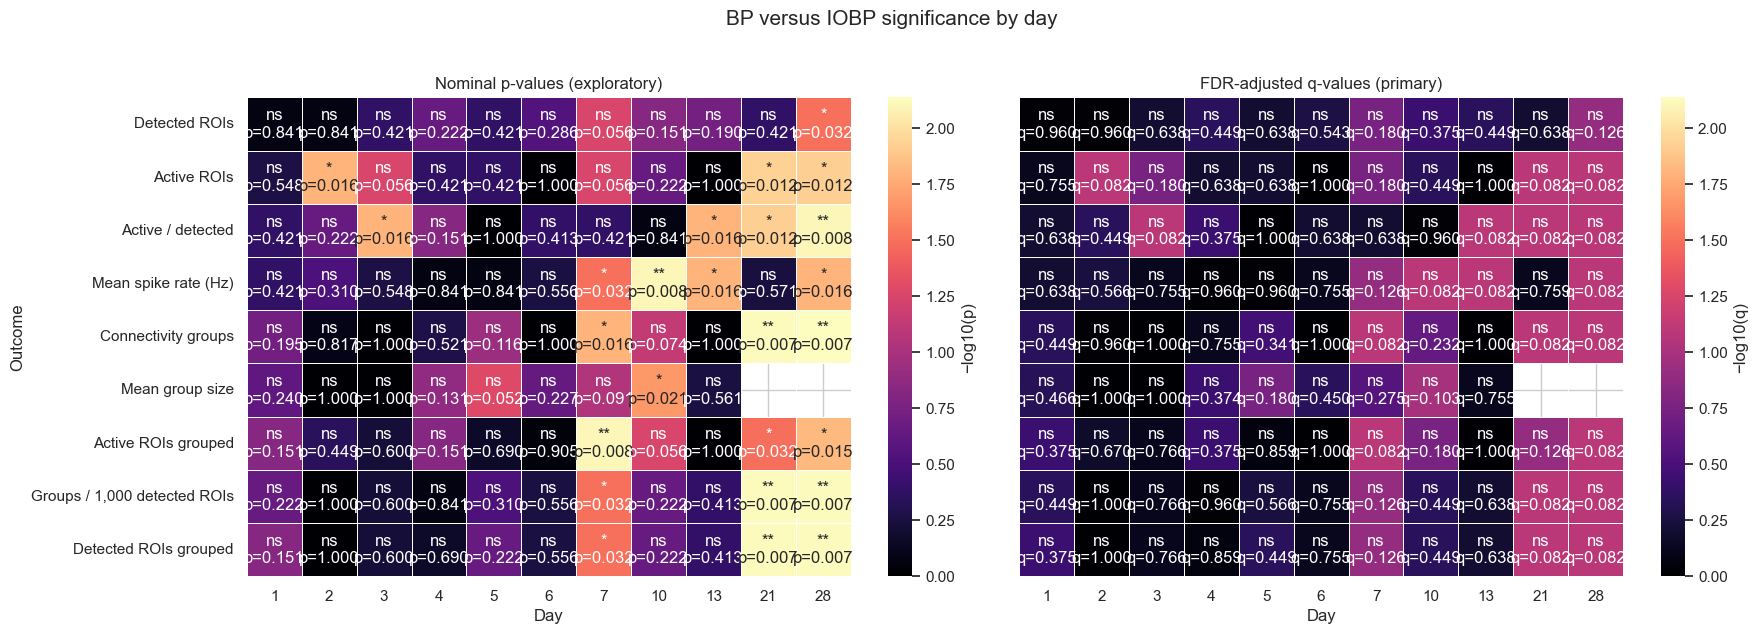

No BP–IOBP comparisons meet FDR q < 0.05; nominal patterns are shown for context.


In [10]:
def significance_stars(pvalue):
    if pd.isna(pvalue):
        return "NA"
    if pvalue < 0.0001:
        return "****"
    if pvalue < 0.001:
        return "***"
    if pvalue < 0.01:
        return "**"
    if pvalue < 0.05:
        return "*"
    return "ns"


comparison_df["nominal_significance"] = comparison_df["p_value"].map(significance_stars)
comparison_df["fdr_significance"] = comparison_df["p_fdr_bh"].map(significance_stars)

outcome_order = list(outcomes.values())


def significance_matrix(value_column):
    return (
        comparison_df.pivot(index="outcome", columns="day", values=value_column)
        .reindex(index=outcome_order, columns=day_order)
    )


p_matrix = significance_matrix("p_value")
q_matrix = significance_matrix("p_fdr_bh")
finite_values = np.concatenate([
    p_matrix.to_numpy(dtype=float).ravel(),
    q_matrix.to_numpy(dtype=float).ravel(),
])
finite_values = finite_values[np.isfinite(finite_values) & (finite_values > 0)]
vmax = max(2.0, float(-np.log10(finite_values.min()))) if len(finite_values) else 2.0

fig, axes = plt.subplots(1, 2, figsize=(18, 6.2), sharey=True)
panels = [
    (axes[0], p_matrix, "Nominal p-values (exploratory)", "p"),
    (axes[1], q_matrix, "FDR-adjusted q-values (primary)", "q"),
]

for ax, matrix, title, symbol in panels:
    score = -np.log10(matrix.clip(lower=np.finfo(float).tiny))
    annotations = matrix.copy().astype(object)
    for outcome in matrix.index:
        for day in matrix.columns:
            value = matrix.loc[outcome, day]
            annotations.loc[outcome, day] = (
                "NA" if pd.isna(value)
                else f"{significance_stars(value)}\n{symbol}={value:.3f}"
            )
    sns.heatmap(
        score,
        annot=annotations,
        fmt="",
        cmap="magma",
        vmin=0,
        vmax=vmax,
        linewidths=0.7,
        linecolor="white",
        cbar_kws={"label": f"−log10({symbol})"},
        ax=ax,
    )
    ax.set(title=title, xlabel="Day", ylabel="Outcome" if ax is axes[0] else "")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("BP versus IOBP significance by day", y=1.02, fontsize=15)
finish_figure(fig, "07_bp_vs_iobp_significance_heatmap.png")

significant_fdr = comparison_df.loc[
    comparison_df["p_fdr_bh"].lt(0.05),
    ["outcome", "day", "median_difference_IOBP_minus_BP", "p_value", "p_fdr_bh"],
]
if significant_fdr.empty:
    print("No BP–IOBP comparisons meet FDR q < 0.05; nominal patterns are shown for context.")
else:
    display(significant_fdr.sort_values("p_fdr_bh"))

## Within-treatment changes between days

Each outcome below gets its own day-by-day heatmap, with **BP and IOBP analyzed separately**. Rows and columns are day timepoints. Only the upper triangle is shown because the lower triangle would duplicate the same comparison. Tile color is a diverging scale for the signed mean change from row day to column day (blue = decrease, red = increase), with a common magnitude scale for BP and IOBP within each outcome.

Recording IDs are matched across the two days, so the default analysis is a **paired t-test** on recording-level values. FDR correction is applied separately to the 28 day-pair tests within each outcome and treatment. Each cell reports the direction, exact mean change (`Δ`), FDR-adjusted q-value, and significance label. Thus color and `Δ` encode effect magnitude/direction, while stars and q-values encode significance. The exported results also include the unadjusted p-value and number of matched recordings.

Set `DAY_PAIR_TEST = "wilcoxon"` for a rank-based alternative. With only 4–5 matched recordings, an exact two-sided Wilcoxon test has coarse p-value resolution and correspondingly low power.

,treatment,outcome,day_row,day_col,n_pairs,mean_change_col_minus_row,p_value,p_fdr_bh,significance
630,IOBP,Active / detected,3,21,5,0.5610,0.0000,0.0003,***
622,IOBP,Active / detected,2,21,5,0.5824,0.0000,0.0003,***
623,IOBP,Active / detected,2,28,5,0.7506,0.0000,0.0003,***
613,IOBP,Active / detected,1,21,5,0.5816,0.0000,0.0003,***
614,IOBP,Active / detected,1,28,5,0.7499,0.0000,0.0003,***
631,IOBP,Active / detected,3,28,5,0.7293,0.0000,0.0003,***
638,IOBP,Active / detected,4,28,5,0.7008,0.0000,0.0003,***
637,IOBP,Active / detected,4,21,5,0.5326,0.0000,0.0003,***
621,IOBP,Active / detected,2,13,4,0.5968,0.0001,0.0005,***
636,IOBP,Active / detected,4,13,4,0.5513,0.0001,0.0005,***


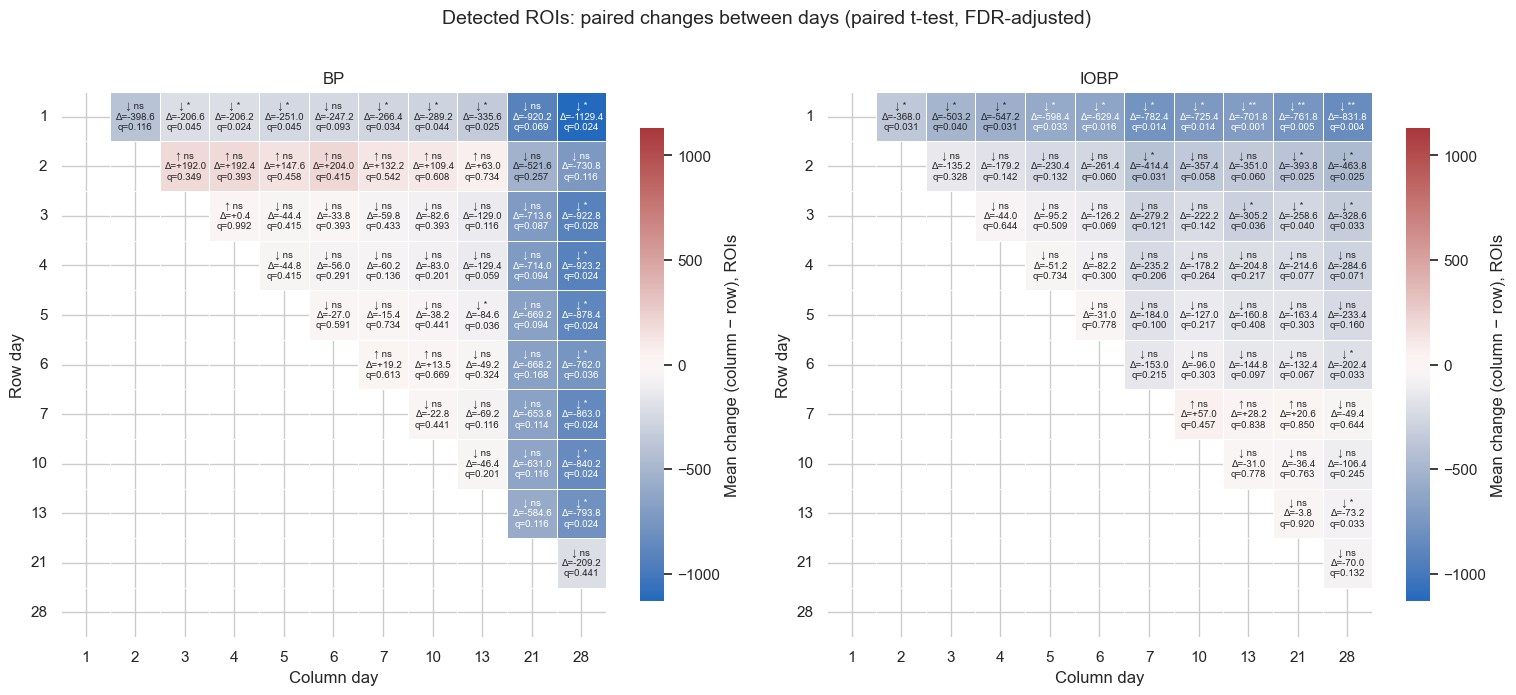

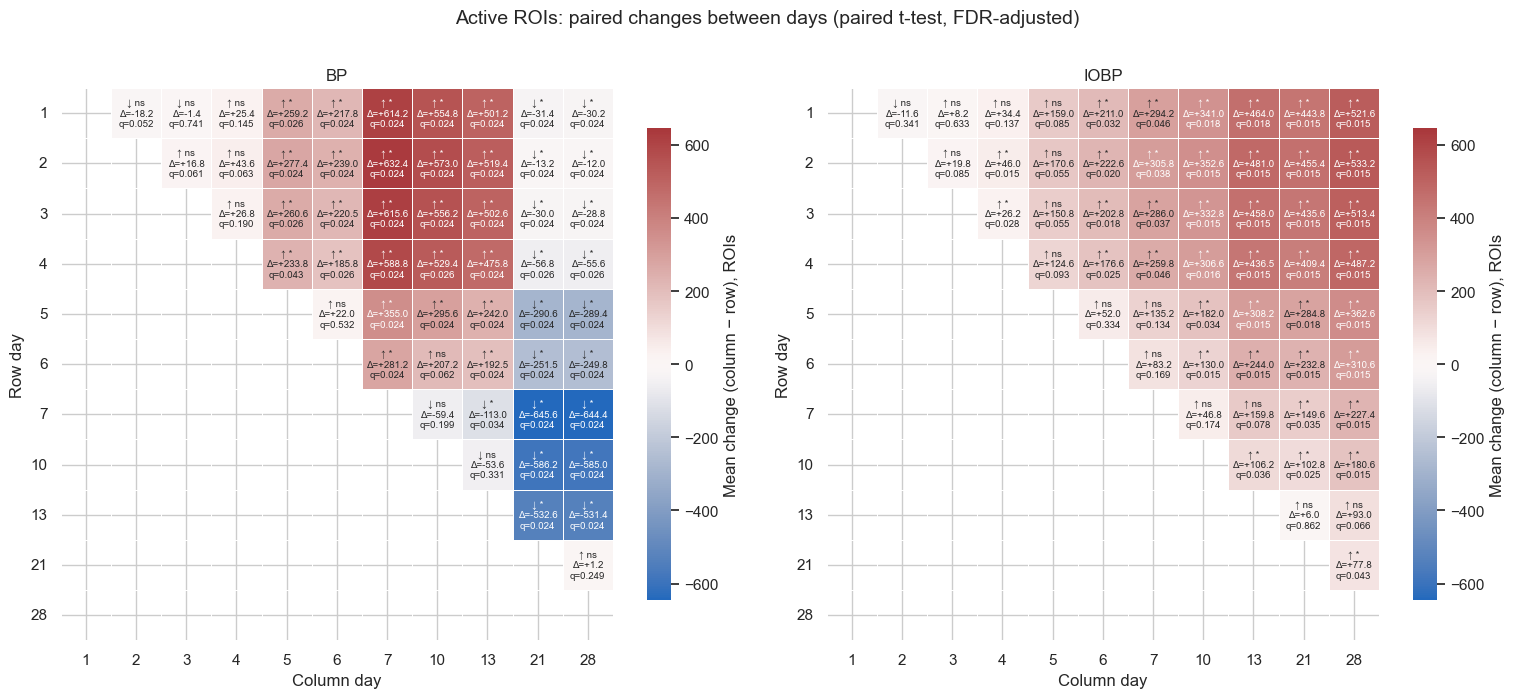

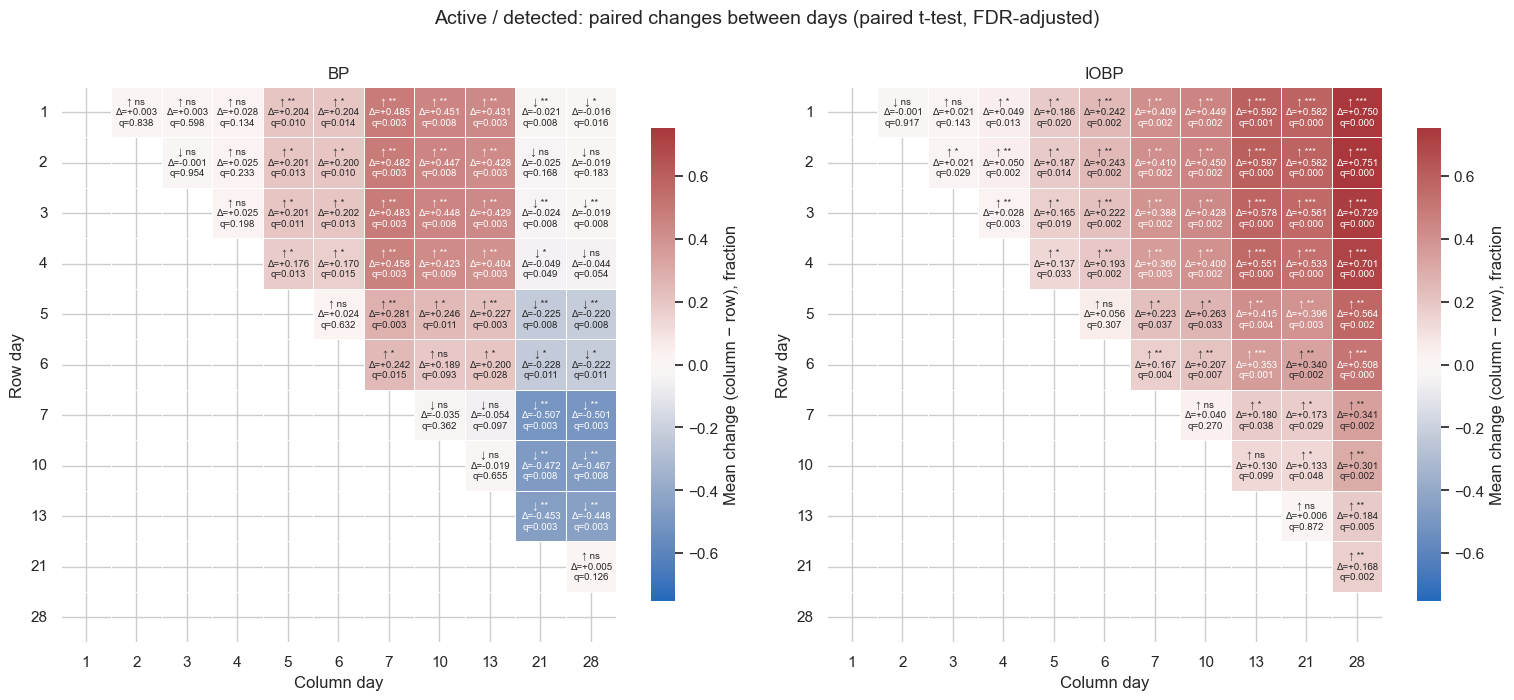

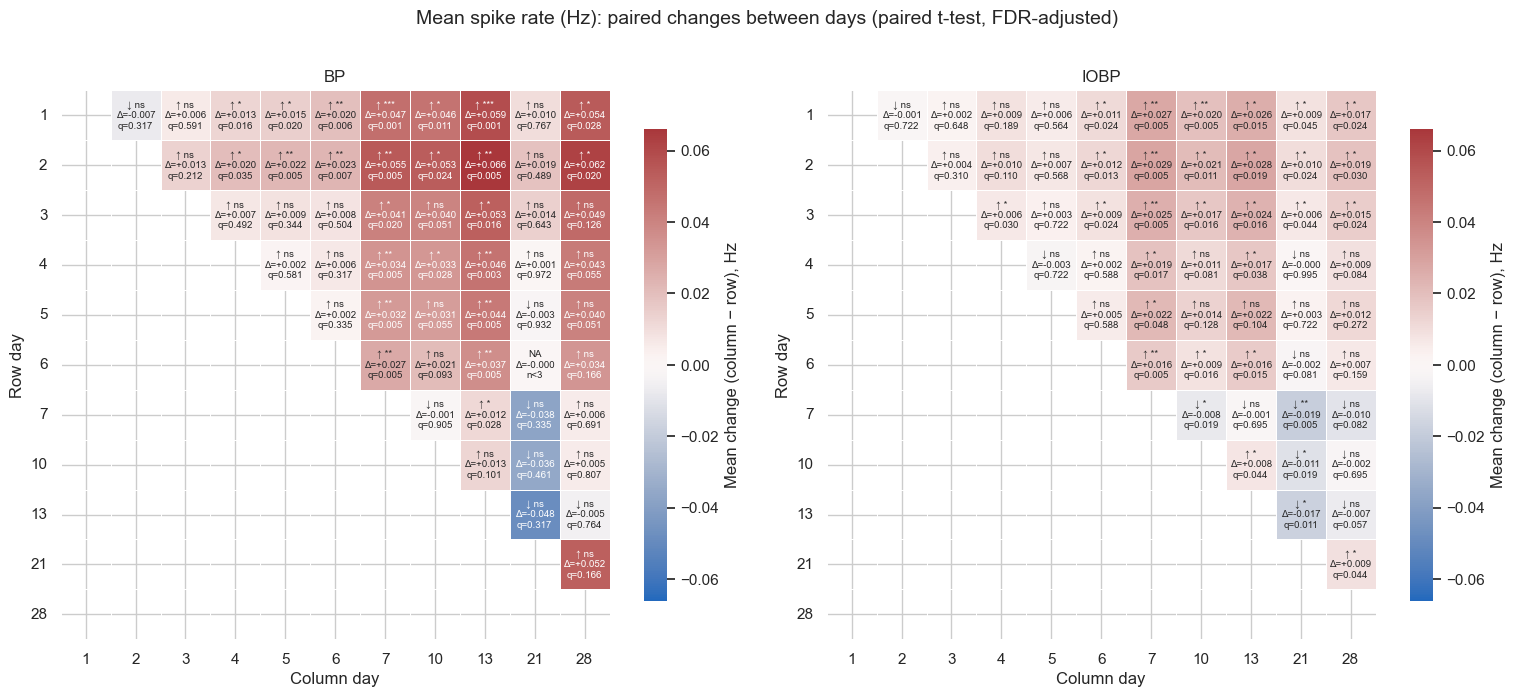

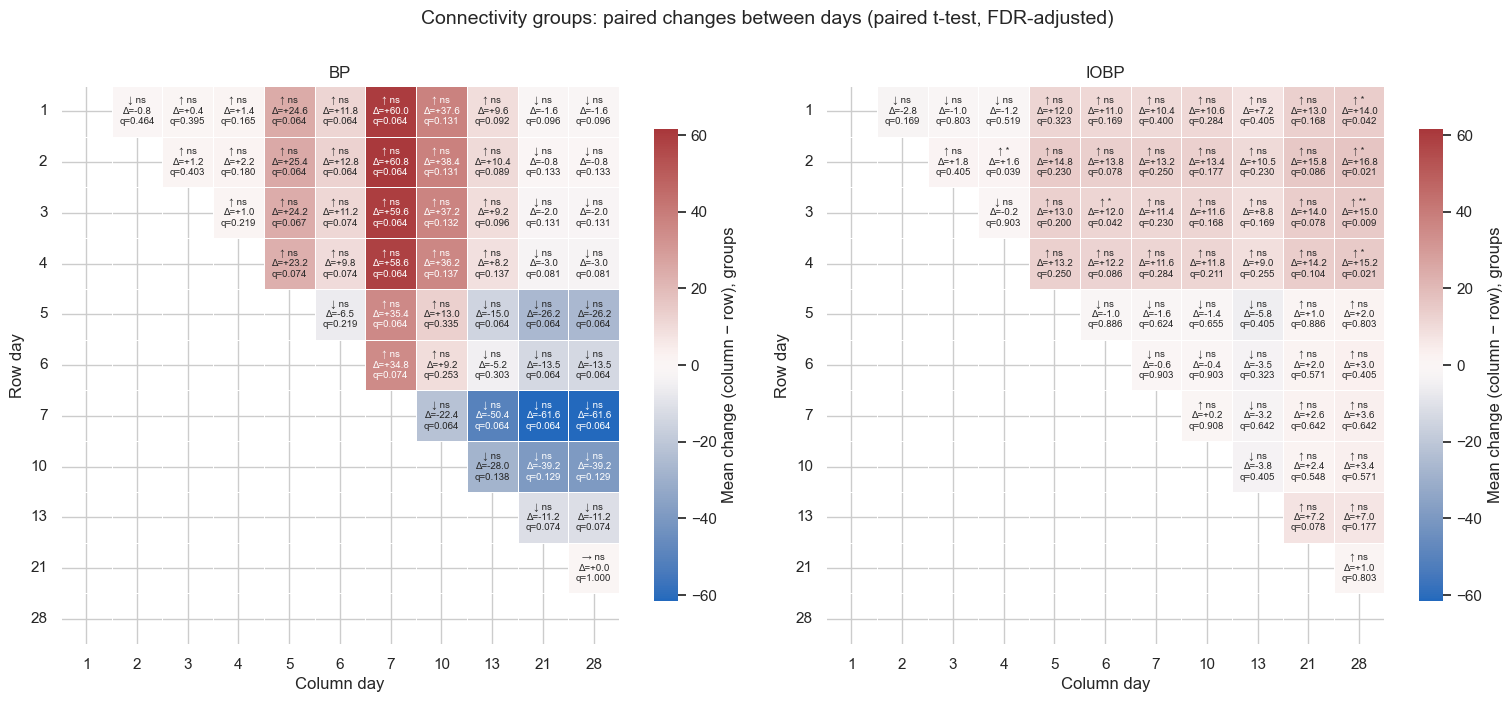

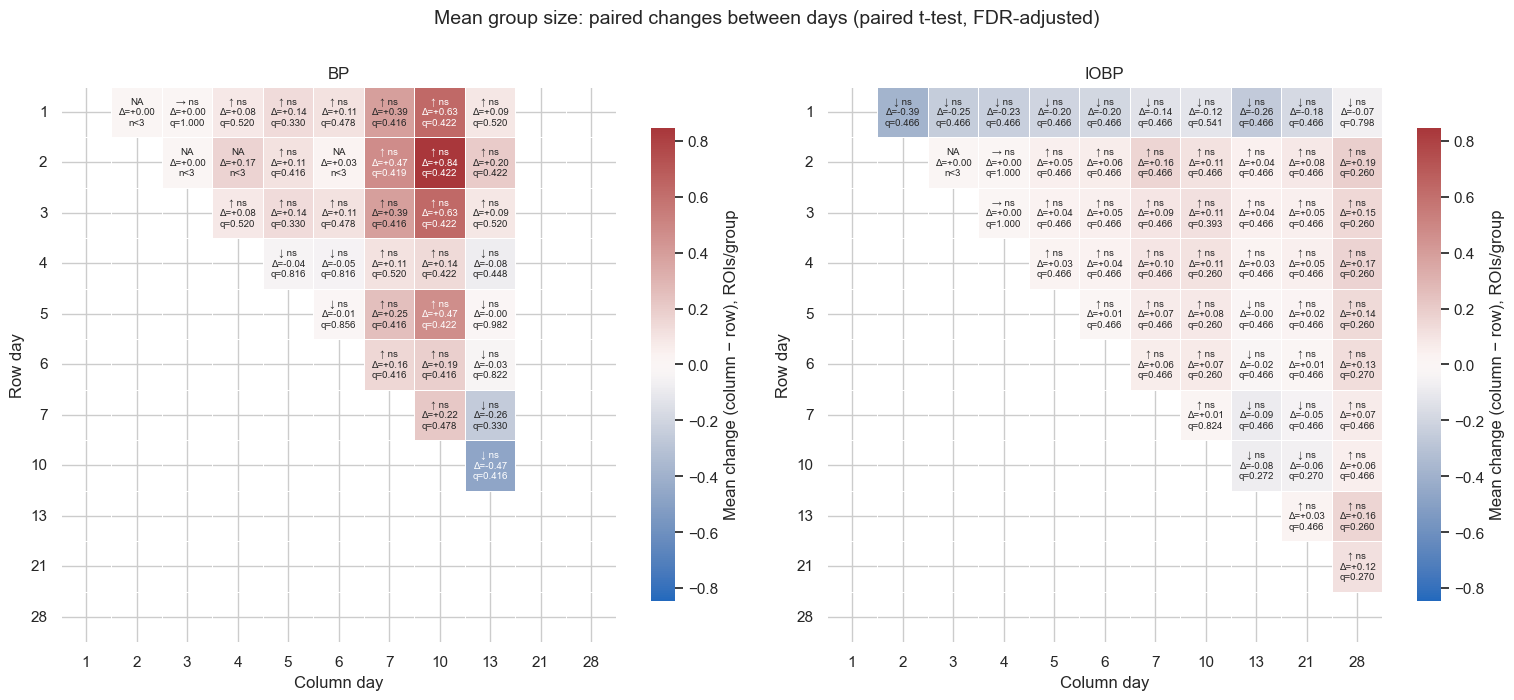

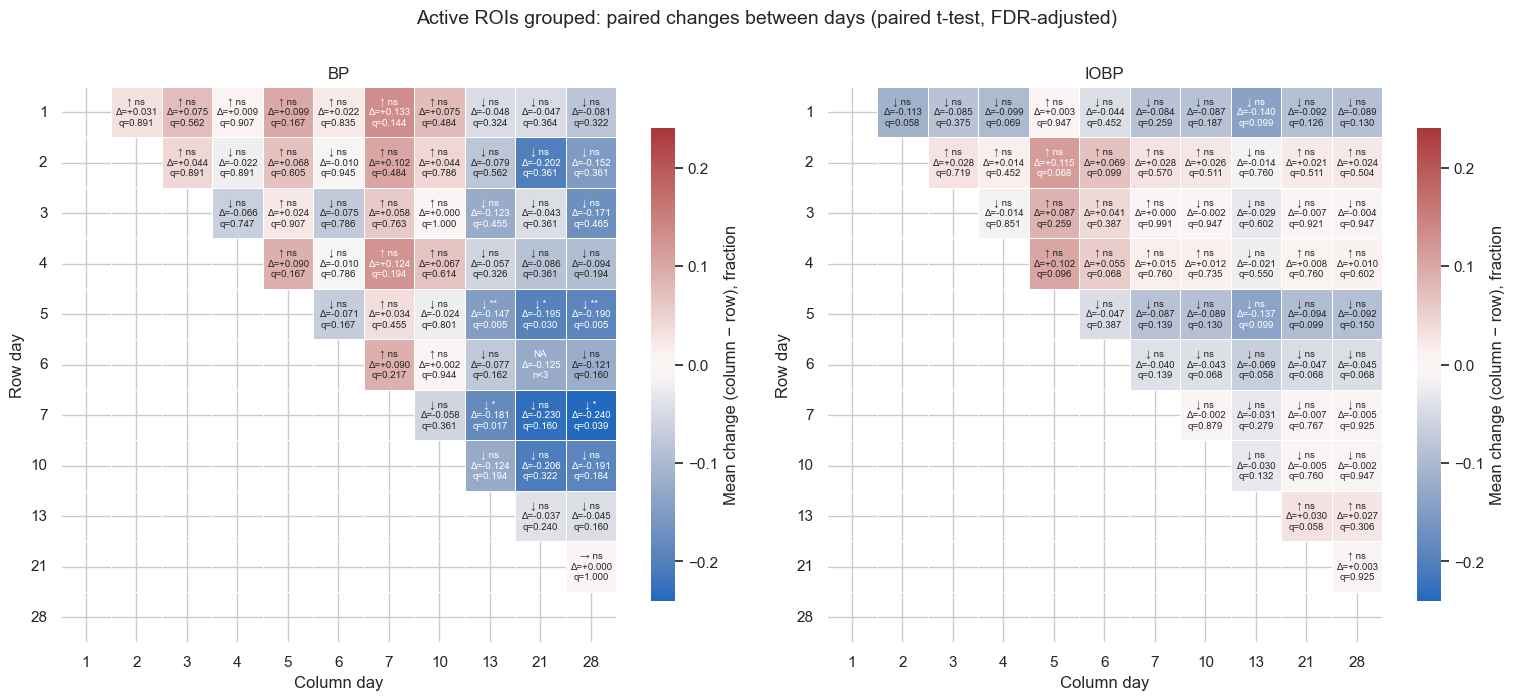

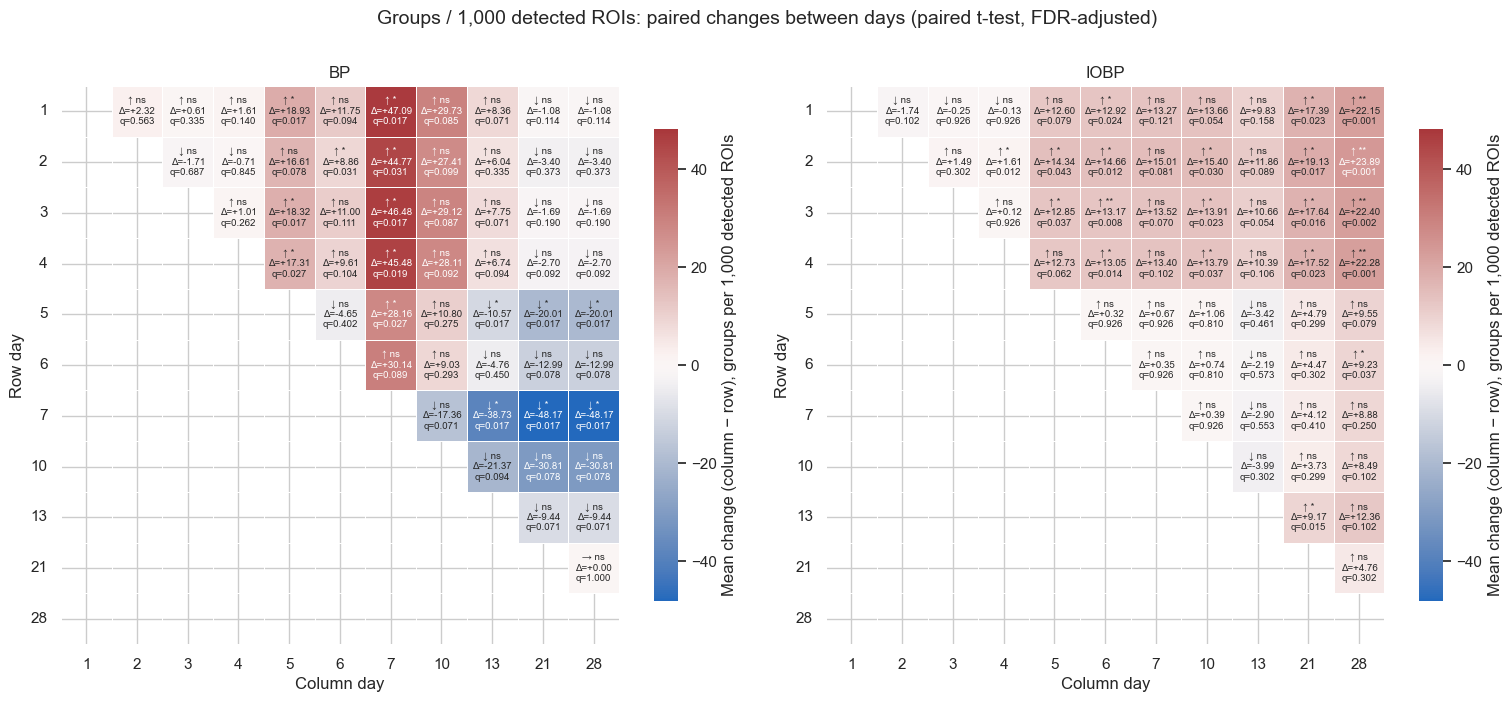

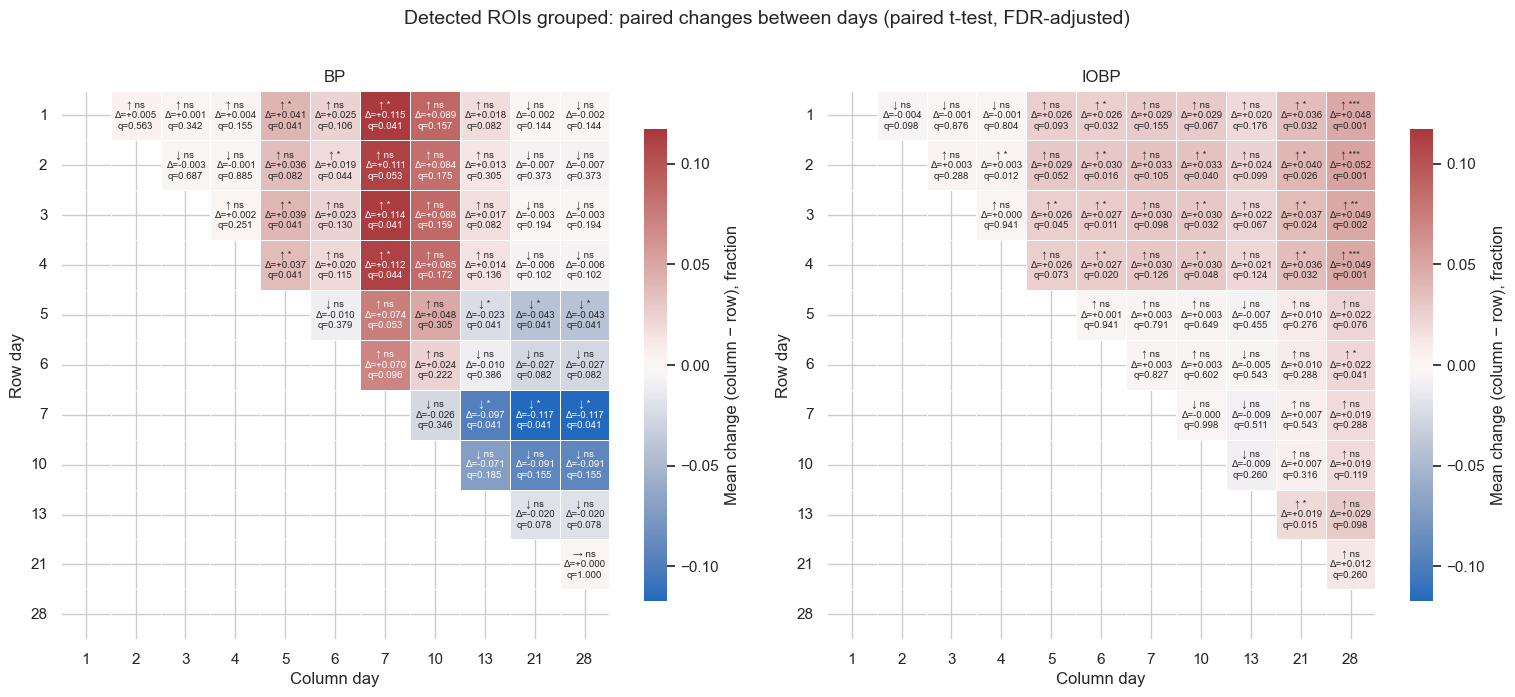

FDR-significant day pairs: 339 of 990 tested comparisons.


In [11]:
DAY_PAIR_TEST = "paired_t"  # Options: "paired_t" or "wilcoxon"


def paired_day_test(x, y, method):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    difference = y - x
    if len(difference) < 3:
        return np.nan, np.nan
    if np.allclose(difference, 0, equal_nan=False):
        return 0.0, 1.0
    if method == "paired_t":
        result = stats.ttest_rel(x, y, nan_policy="omit")
    elif method == "wilcoxon":
        result = stats.wilcoxon(x, y, alternative="two-sided", method="auto")
    else:
        raise ValueError("DAY_PAIR_TEST must be 'paired_t' or 'wilcoxon'")
    return float(result.statistic), float(result.pvalue)


def within_treatment_day_comparisons(data, metric_map, method="paired_t"):
    rows = []
    for treatment in TREATMENT_ORDER:
        treatment_data = data.loc[data["treatment"].eq(treatment)]
        for metric, label in metric_map.items():
            wide = treatment_data.pivot(index="recording", columns="day", values=metric)
            for i, day_row in enumerate(day_order):
                for day_col in day_order[i + 1:]:
                    if day_row not in wide or day_col not in wide:
                        continue
                    matched = wide[[day_row, day_col]].dropna()
                    x = matched[day_row].to_numpy(dtype=float)
                    y = matched[day_col].to_numpy(dtype=float)
                    statistic, pvalue = paired_day_test(x, y, method)
                    rows.append({
                        "treatment": treatment,
                        "metric": metric,
                        "outcome": label,
                        "day_row": day_row,
                        "day_col": day_col,
                        "n_pairs": len(matched),
                        "mean_day_row": np.mean(x) if len(x) else np.nan,
                        "mean_day_col": np.mean(y) if len(y) else np.nan,
                        "mean_change_col_minus_row": np.mean(y - x) if len(x) else np.nan,
                        "statistic": statistic,
                        "p_value": pvalue,
                        "test": method,
                    })
    result = pd.DataFrame(rows)
    result["p_fdr_bh"] = np.nan
    for (_, _), idx in result.groupby(["treatment", "metric"]).groups.items():
        result.loc[idx, "p_fdr_bh"] = bh_adjust(result.loc[idx, "p_value"].to_numpy())
    result["significance"] = result["p_fdr_bh"].map(significance_stars)
    result["fdr_0.05"] = result["p_fdr_bh"].lt(0.05)
    return result


day_pair_df = within_treatment_day_comparisons(
    recording_df, outcomes, method=DAY_PAIR_TEST
)
display(
    day_pair_df.sort_values("p_fdr_bh")
    .loc[:, ["treatment", "outcome", "day_row", "day_col", "n_pairs",
             "mean_change_col_minus_row", "p_value", "p_fdr_bh", "significance"]]
    .head(25)
    .round(4)
)


def day_pair_matrices(pair_data, treatment, metric):
    q_matrix = pd.DataFrame(np.nan, index=day_order, columns=day_order, dtype=float)
    delta_matrix = pd.DataFrame(np.nan, index=day_order, columns=day_order, dtype=float)
    annotations = pd.DataFrame("", index=day_order, columns=day_order, dtype=object)
    subset = pair_data.loc[
        pair_data["treatment"].eq(treatment) & pair_data["metric"].eq(metric)
    ]
    for row in subset.itertuples(index=False):
        q_matrix.loc[row.day_row, row.day_col] = row.p_fdr_bh
        delta_matrix.loc[row.day_row, row.day_col] = row.mean_change_col_minus_row
        direction = (
            "↑" if row.mean_change_col_minus_row > 0
            else "↓" if row.mean_change_col_minus_row < 0
            else "→"
        )
        decimals = {
            "detected_roi_count": 1, "active_roi_count": 1,
            "active_fraction": 3, "mean_spike_rate_hz": 3,
            "n_groups": 1, "mean_group_size": 2,
            "fraction_active_grouped": 3,
            "groups_per_1000_detected_rois": 2,
            "fraction_detected_rois_grouped": 3,
        }[metric]
        delta_text = f"{row.mean_change_col_minus_row:+.{decimals}f}"
        annotations.loc[row.day_row, row.day_col] = (
            f"NA\nΔ={delta_text}\nn<3" if pd.isna(row.p_fdr_bh)
            else (
                f"{direction} {significance_stars(row.p_fdr_bh)}\n"
                f"Δ={delta_text}\nq={row.p_fdr_bh:.3f}"
            )
        )
    return q_matrix, delta_matrix, annotations


metric_slugs = {
    "detected_roi_count": "detected_rois",
    "active_roi_count": "active_rois",
    "active_fraction": "active_fraction",
    "mean_spike_rate_hz": "mean_spike_rate",
    "n_groups": "connectivity_groups",
    "mean_group_size": "mean_group_size",
    "fraction_active_grouped": "fraction_active_grouped",
    "groups_per_1000_detected_rois": "groups_per_1000_detected_rois",
    "fraction_detected_rois_grouped": "fraction_detected_rois_grouped",
}
metric_change_units = {
    "detected_roi_count": "ROIs",
    "active_roi_count": "ROIs",
    "active_fraction": "fraction",
    "mean_spike_rate_hz": "Hz",
    "n_groups": "groups",
    "mean_group_size": "ROIs/group",
    "fraction_active_grouped": "fraction",
    "groups_per_1000_detected_rois": "groups per 1,000 detected ROIs",
    "fraction_detected_rois_grouped": "fraction",
}

for metric, label in outcomes.items():
    matrices = {
        treatment: day_pair_matrices(day_pair_df, treatment, metric)
        for treatment in TREATMENT_ORDER
    }
    all_delta = np.concatenate([
        delta_matrix.to_numpy(dtype=float).ravel()
        for _, delta_matrix, _ in matrices.values()
    ])
    all_delta = all_delta[np.isfinite(all_delta)]
    max_abs_change = float(np.max(np.abs(all_delta))) if len(all_delta) else 1.0
    if max_abs_change == 0:
        max_abs_change = 1.0

    fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.6))
    for ax, treatment in zip(axes, TREATMENT_ORDER):
        q_matrix, delta_matrix, annotations = matrices[treatment]
        mask = np.tril(np.ones(q_matrix.shape, dtype=bool), k=0)
        sns.heatmap(
            delta_matrix,
            mask=mask,
            annot=annotations,
            annot_kws={"fontsize": 7},
            fmt="",
            cmap="vlag",
            center=0,
            vmin=-max_abs_change,
            vmax=max_abs_change,
            linewidths=0.7,
            linecolor="white",
            square=True,
            cbar_kws={
                "label": (
                    f"Mean change (column − row), {metric_change_units[metric]}"
                ),
                "shrink": 0.82,
            },
            ax=ax,
        )
        ax.set(
            title=f"{treatment}",
            xlabel="Column day",
            ylabel="Row day",
        )
        ax.tick_params(axis="x", rotation=0)
        ax.tick_params(axis="y", rotation=0)

    test_label = "paired t-test" if DAY_PAIR_TEST == "paired_t" else "paired Wilcoxon"
    fig.suptitle(
        f"{label}: paired changes between days ({test_label}, FDR-adjusted)",
        y=1.02,
        fontsize=14,
    )
    finish_figure(fig, f"08_day_pairwise_{metric_slugs[metric]}.png")

day_pair_df.to_csv(
    OUTPUT_DIR / "within_treatment_day_pairwise_tests.csv", index=False
)
print(
    f"FDR-significant day pairs: {int(day_pair_df['fdr_0.05'].sum())} of "
    f"{len(day_pair_df)} tested comparisons."
)

## Day-stratified summary tables and exports

In [12]:
summary_by_day = (
    recording_df.groupby(["day", "treatment"], observed=True)
    .agg(
        n_recordings=("recording", "size"),
        detected_roi_mean=("detected_roi_count", "mean"),
        detected_roi_sd=("detected_roi_count", "std"),
        active_roi_mean=("active_roi_count", "mean"),
        active_roi_sd=("active_roi_count", "std"),
        active_fraction_mean=("active_fraction", "mean"),
        active_fraction_sd=("active_fraction", "std"),
        spike_rate_mean_hz=("mean_spike_rate_hz", "mean"),
        spike_rate_sd_hz=("mean_spike_rate_hz", "std"),
        group_count_mean=("n_groups", "mean"),
        group_count_sd=("n_groups", "std"),
        group_size_mean=("mean_group_size", "mean"),
        group_size_sd=("mean_group_size", "std"),
        fraction_grouped_mean=("fraction_active_grouped", "mean"),
        fraction_grouped_sd=("fraction_active_grouped", "std"),
        groups_per_1000_detected_mean=("groups_per_1000_detected_rois", "mean"),
        groups_per_1000_detected_sd=("groups_per_1000_detected_rois", "std"),
        fraction_detected_grouped_mean=("fraction_detected_rois_grouped", "mean"),
        fraction_detected_grouped_sd=("fraction_detected_rois_grouped", "std"),
    )
    .reset_index()
)
display(summary_by_day.round(3))

recording_df.to_csv(OUTPUT_DIR / "recording_level_metrics.csv", index=False)
spike_export_cols = [
    "treatment", "recording", "day", "recording_folder",
    "neuron_idx", "filtered_index", "spike_frequency", "number_of_spikes",
]
spike_df.loc[:, spike_export_cols].to_csv(
    OUTPUT_DIR / "active_neuron_spike_rates.csv", index=False
)
group_df.to_csv(OUTPUT_DIR / "connectivity_groups.csv", index=False)
summary_by_day.to_csv(OUTPUT_DIR / "day_stratified_summary.csv", index=False)
comparison_df.to_csv(OUTPUT_DIR / "bp_vs_iobp_by_day.csv", index=False)
print(f"Saved tables and figures to: {OUTPUT_DIR.resolve()}")

,day,treatment,n_recordings,detected_roi_mean,detected_roi_sd,active_roi_mean,active_roi_sd,active_fraction_mean,active_fraction_sd,spike_rate_mean_hz,...,group_count_mean,group_count_sd,group_size_mean,group_size_sd,fraction_grouped_mean,fraction_grouped_sd,groups_per_1000_detected_mean,groups_per_1000_detected_sd,fraction_detected_grouped_mean,fraction_detected_grouped_sd
0,1,BP,5,1518.40,461.166,32.2,9.680,0.022,0.007,0.060,...,1.60,1.342,2.000,0.000,0.090,0.069,1.083,1.043,0.002,0.002
1,1,IOBP,5,1551.60,185.554,42.8,16.962,0.028,0.012,0.062,...,3.40,2.302,2.233,0.435,0.157,0.065,2.300,1.608,0.005,0.003
2,2,BP,5,1119.80,686.103,14.0,6.442,0.026,0.030,0.052,...,0.80,0.837,2.000,0.000,0.121,0.164,3.403,6.909,0.007,0.014
3,2,IOBP,5,1183.60,277.443,31.2,8.044,0.027,0.008,0.061,...,0.60,0.548,2.000,0.000,0.044,0.043,0.557,0.570,0.001,0.001
4,3,BP,5,1311.80,437.692,30.8,9.094,0.025,0.009,0.066,...,2.00,2.000,2.000,0.000,0.165,0.224,1.689,2.089,0.003,0.004
5,3,IOBP,5,1048.40,273.800,51.0,21.272,0.049,0.014,0.065,...,2.40,3.209,2.000,0.000,0.073,0.070,2.051,2.136,0.004,0.004
6,4,BP,5,1312.20,407.985,57.6,32.693,0.050,0.035,0.072,...,3.00,2.236,2.146,0.172,0.099,0.056,2.697,2.198,0.006,0.005
7,4,IOBP,5,1004.40,274.575,77.2,23.510,0.077,0.015,0.071,...,2.20,0.837,2.000,0.000,0.058,0.023,2.168,0.586,0.004,0.001
8,5,BP,5,1267.40,378.941,291.4,153.389,0.226,0.078,0.074,...,26.20,14.957,2.124,0.062,0.189,0.015,20.009,6.725,0.043,0.016
9,5,IOBP,5,953.20,415.675,201.8,134.635,0.214,0.098,0.068,...,15.40,15.143,2.029,0.064,0.160,0.073,14.898,8.117,0.031,0.018


Saved tables and figures to: C:\Users\mzinn1\Desktop\Scripts\GCaMP-analysis\notebooks\visualization_outputs_all_timepoints
